# House Prices — Advanced Regression Techniques

**Competição:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques  
**Autora:** Juliana Burato  
**Algoritmo:** LightGBM  
**RMSLE no Kaggle:** 0.12949

---

## Descrição

Previsão do preço de venda de casas em Ames, Iowa (EUA) a partir de 79 variáveis
sobre características físicas, qualidade e localização dos imóveis.

## Fluxo

```
train.csv / test.csv
    → EDA
    → Tratamento de NaN (por grupo: None / 0 / mediana do bairro)
    → Encoding ordinal (variáveis com ordem natural)
    → Feature engineering (áreas compostas, features temporais, flags, interações)
    → One-Hot Encoding
    → LightGBM + GridSearchCV (5-fold CV)
    → submission.csv
```


## 1. Imports

In [1]:
!pip install lightgbm --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

print('OK')


OK


## 2. Dados

| Arquivo | Linhas | Colunas |
|---|---|---|
| `train.csv` | 1.460 | 81 (79 features + Id + SalePrice) |
| `test.csv` | 1.459 | 80 (79 features + Id) |

Os dados estão no Google Drive em:
```
MyDrive/kaggle_house_prices/
```


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
train = pd.read_csv('/content/drive/MyDrive/kaggle_house prices/train.csv')
test  = pd.read_csv('/content/drive/MyDrive/kaggle_house prices/test.csv')
test_ids = test['Id'].copy()

print(f'train: {train.shape}')
print(f'test:  {test.shape}')


train: (1460, 81)
test:  (1459, 80)


## 3. Análise Exploratória

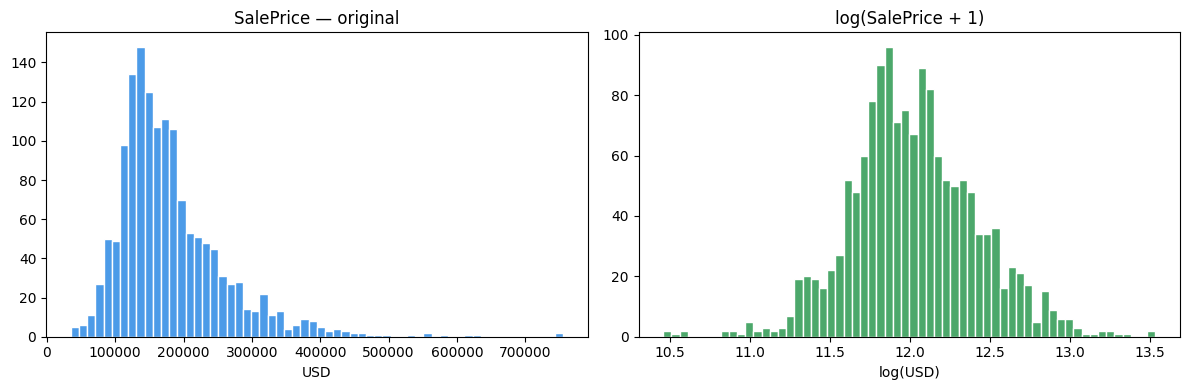

Skewness original:   1.883
Skewness após log:   0.121


In [5]:
# SalePrice tem skew positivo — log1p reduz a assimetria e alinha com a métrica RMSLE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['SalePrice'], bins=60, color='#4C9BE8', edgecolor='white', lw=0.5)
axes[0].set_title('SalePrice — original')
axes[0].set_xlabel('USD')

axes[1].hist(np.log1p(train['SalePrice']), bins=60, color='#4CA86B', edgecolor='white', lw=0.5)
axes[1].set_title('log(SalePrice + 1)')
axes[1].set_xlabel('log(USD)')

plt.tight_layout()
plt.show()

print(f'Skewness original:   {train["SalePrice"].skew():.3f}')
print(f'Skewness após log:   {np.log1p(train["SalePrice"]).skew():.3f}')


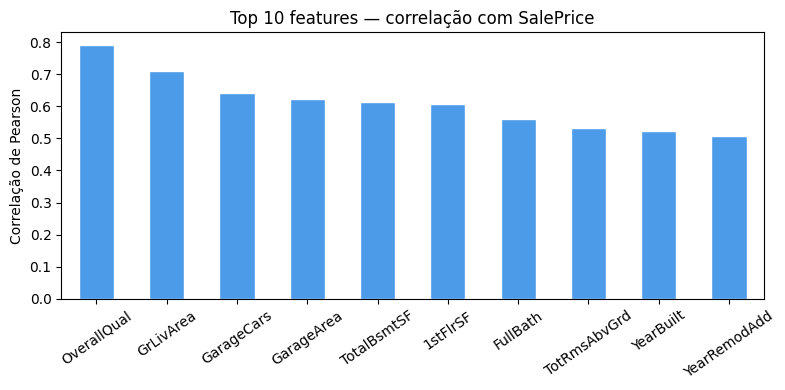

In [6]:
# OverallQual lidera com folga — qualidade construtiva tem maior impacto no preço
numericas = train.select_dtypes(include=[np.number]).columns
corr = train[numericas].corr()['SalePrice'].drop('SalePrice')
top10 = corr.abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))
corr[top10.index].plot(kind='bar', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Top 10 features — correlação com SalePrice')
ax.set_ylabel('Correlação de Pearson')
ax.tick_params(axis='x', rotation=35)
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()


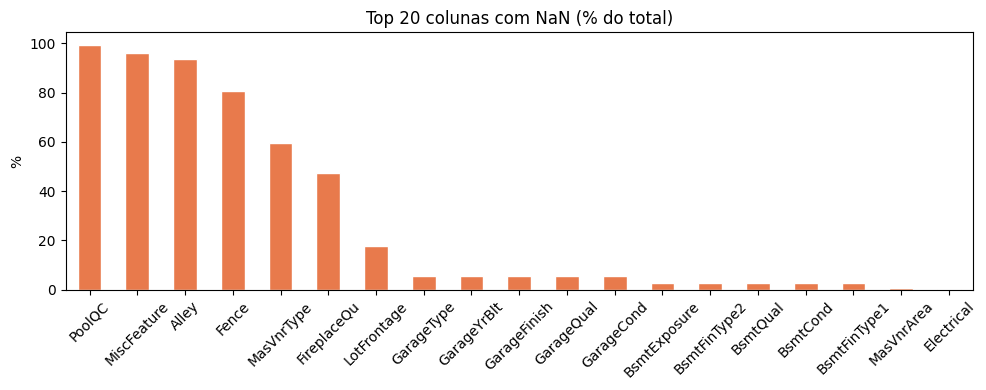

In [7]:
# Valores ausentes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
(missing / len(train) * 100).head(20).plot(kind='bar', ax=ax,
                                             color='#E87A4C', edgecolor='white')
ax.set_title('Top 20 colunas com NaN (% do total)')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 4. Pré-processamento

Target transformado com `log1p` para reduzir skewness e alinhar com a métrica RMSLE.
Treino e teste concatenados antes das transformações para garantir encoding consistente.


In [8]:
n_train = len(train)
# log1p no target — minimizar RMSE no espaço log equivale a minimizar RMSLE
y = np.log1p(train['SalePrice'].values)

# Concatenar antes das transformações garante colunas idênticas após one-hot
all_data = pd.concat(
    [train.drop(['SalePrice', 'Id'], axis=1),
     test.drop('Id', axis=1)],
    ignore_index=True
)

print(f'all_data: {all_data.shape}')


all_data: (2919, 79)


## 5. Tratamento de NaN

NaN neste dataset raramente indica dado faltante — na maioria dos casos indica ausência da feature.
Estratégia definida por grupo:

| Grupo | Estratégia | Critério |
|---|---|---|
| Categóricas de ausência | `'None'` | Feature inexistente (ex: sem piscina → `PoolQC = None`) |
| Numéricas de ausência | `0` | Medida zero por inexistência (ex: sem garagem → `GarageArea = 0`) |
| `LotFrontage` | Mediana por bairro | Correlação espacial entre vizinhos |
| Demais categóricas | Moda | Poucos NaN, sem padrão específico |


In [9]:
# NaN aqui raramente significa dado faltante — indica ausência da feature
# Categóricas: 'None' preserva a informação de ausência para o encoding ordinal
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
            'BsmtFinType2', 'MasVnrType']:
    all_data[col] = all_data[col].fillna('None')

# Numéricas: 0 é semanticamente correto (ex: GarageArea=0 = sem garagem)
for col in ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
            'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
            'BsmtHalfBath', 'MasVnrArea']:
    all_data[col] = all_data[col].fillna(0)

# LotFrontage: mediana por bairro — correlação espacial mais forte que mediana global
all_data['LotFrontage'] = (all_data.groupby('Neighborhood')['LotFrontage']
                            .transform(lambda x: x.fillna(x.median())))

# Demais: poucos NaN sem padrão claro — moda é suficiente
for col in ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
            'Exterior2nd', 'Functional', 'SaleType', 'Utilities']:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f'NaN restantes: {all_data.isnull().sum().sum()}')


NaN restantes: 0


## 6. Encoding Ordinal

Variáveis com hierarquia natural convertidas para inteiros preservando a ordem.
`None = 0` representa ausência da feature.


In [10]:
# Encoding ordinal preserva a hierarquia: Ex > Gd > TA > Fa > Po > None
# One-hot nessas colunas perderia a informação de ordem
qual = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

encodings = {
    'ExterQual': qual, 'ExterCond': qual, 'BsmtQual': qual, 'BsmtCond': qual,
    'HeatingQC': qual, 'KitchenQual': qual, 'FireplaceQu': qual,
    'GarageQual': qual, 'GarageCond': qual, 'PoolQC': qual,
    'BsmtExposure': {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2': {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'GarageFinish': {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Fence':        {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'Functional':   {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'Street':       {'Grvl': 0, 'Pave': 1},
    'Alley':        {'None': 0, 'Grvl': 1, 'Pave': 2},
    'PavedDrive':   {'N': 0, 'P': 1, 'Y': 2},
}

for col, mapa in encodings.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapa).fillna(0)

print(f'Encoding ordinal aplicado em {len(encodings)} colunas.')


Encoding ordinal aplicado em 19 colunas.


## 7. Feature Engineering

| Feature | Definição |
|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` |
| `TotalBath` | `FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath` |
| `HouseAge` | `YrSold − YearBuilt` |
| `WasRemodeled` | `YearRemodAdd != YearBuilt` |
| `HasGarage` | `GarageArea > 0` |
| `HasBasement` | `TotalBsmtSF > 0` |
| `HasFireplace` | `Fireplaces > 0` |
| `Has2ndFloor` | `2ndFlrSF > 0` |


In [11]:
# Compradores avaliam área total — fragmentar por andar perde essa visão
all_data['TotalSF']      = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
# Convenção do mercado imobiliário: lavabo (half bath) vale 0.5 banheiro
all_data['TotalBath']    = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                            all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                            all_data['3SsnPorch'] + all_data['ScreenPorch'])

# Idade captura depreciação; anos desde reforma captura valorização por atualização
all_data['HouseAge']        = all_data['YrSold'] - all_data['YearBuilt']
all_data['YearsSinceRemod'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['WasRemodeled']    = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
all_data['IsNew']           = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)

# Flags binários — presença/ausência tem impacto não-linear no preço
for col, new in [('GarageArea', 'HasGarage'), ('TotalBsmtSF', 'HasBasement'),
                 ('Fireplaces', 'HasFireplace'), ('2ndFlrSF', 'Has2ndFloor'),
                 ('PoolArea', 'HasPool')]:
    all_data[new] = (all_data[col] > 0).astype(int)

print(f'Features após engineering: {all_data.shape[1]}')


Features após engineering: 91


## 8. One-Hot Encoding

In [12]:
# One-hot nas categóricas restantes — sem hierarquia natural, distâncias são equivalentes
print(f'Shape antes: {all_data.shape}')
all_data = pd.get_dummies(all_data)
print(f'Shape depois: {all_data.shape}')

X_train_full = all_data[:n_train].values
X_test_final = all_data[n_train:].values


Shape antes: (2919, 91)
Shape depois: (2919, 240)


## 9. Modelo — LightGBM

Cross-validation com 5 folds para avaliação antes do GridSearchCV.


In [13]:
# Avaliação inicial com parâmetros padrão — referência antes do GridSearchCV
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y, test_size=0.2, random_state=42
)

model = LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                       num_leaves=31, random_state=42, verbose=-1)
model.fit(X_tr, y_tr)

rmsle_val = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
print(f'RMSLE (validação): {rmsle_val:.4f}')


RMSLE (validação): 0.1389


In [14]:
# 5-fold CV — estimativa mais estável que holdout único; usa 100% dos dados para avaliação
scores = cross_val_score(
    LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                  num_leaves=31, random_state=42, verbose=-1),
    X_train_full, y,
    scoring='neg_mean_squared_error',
    cv=5, n_jobs=-1
)
rmsle_scores = np.sqrt(-scores)

for i, s in enumerate(rmsle_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Média: {rmsle_scores.mean():.4f} ± {rmsle_scores.std():.4f}')


  Fold 1: 0.1234
  Fold 2: 0.1388
  Fold 3: 0.1377
  Fold 4: 0.1196
  Fold 5: 0.1328
  Média: 0.1304 ± 0.0077


## 10. GridSearchCV

In [15]:
# num_leaves controla complexidade — valores altos aumentam capacidade mas podem gerar overfitting
# min_child_samples regula o mínimo de amostras por folha — atua como regularização
params = {
    'n_estimators':      [500, 1000],
    'learning_rate':     [0.05, 0.1],
    'num_leaves':        [31, 63],
    'min_child_samples': [20, 30],
}

grid_search = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train_full, y)

print(f'Melhores parâmetros: {grid_search.best_params_}')
print(f'Melhor RMSLE (CV):   {np.sqrt(-grid_search.best_score_):.4f}')

model = grid_search.best_estimator_


Melhores parâmetros: {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 1000, 'num_leaves': 31}
Melhor RMSLE (CV):   0.1307


## 11. Importância das Features

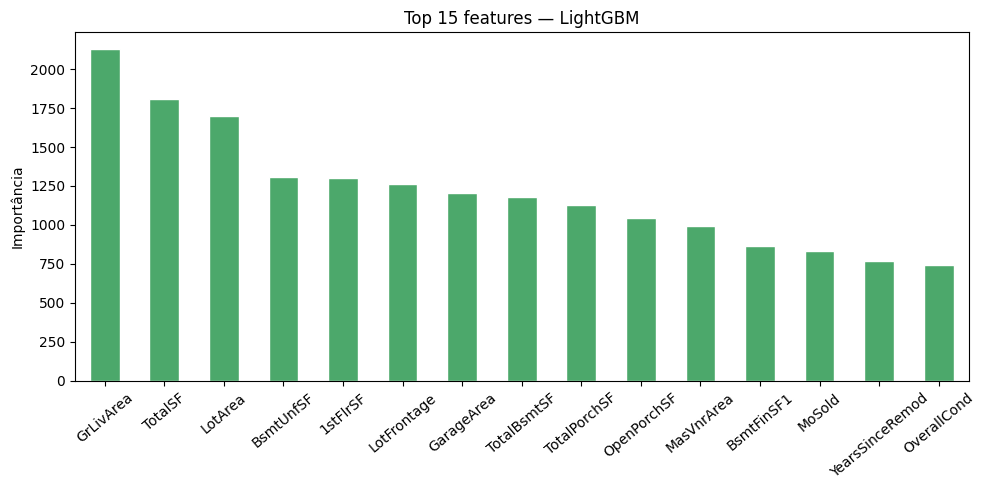

In [16]:
importances = pd.Series(
    model.feature_importances_,
    index=all_data.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot(kind='bar', ax=ax, color='#4CA86B', edgecolor='white')
ax.set_title('Top 15 features — LightGBM')
ax.set_ylabel('Importância')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()


## 12. Submissão

In [17]:
# Retreinar com todos os 1.460 exemplos — mais dados para o modelo final
model.fit(X_train_full, y)

# expm1 reverte o log1p aplicado no target
pred = np.expm1(model.predict(X_test_final))

submission = pd.DataFrame({'Id': test_ids.values, 'SalePrice': pred})
submission.to_csv('submission.csv', index=False)

print(f'submission.csv — {len(submission):,} previsões')
print(f'Mediana: ${np.median(pred):,.0f}')
submission.head(10)


submission.csv — 1,459 previsões
Mediana: $157,881


,Id,SalePrice
0,1461,121288.837256
1,1462,162284.045688
2,1463,187288.592785
3,1464,196671.796932
4,1465,191046.440323
5,1466,172991.828111
6,1467,176658.994497
7,1468,171066.586450
8,1469,177308.002383
9,1470,123919.483243
